In [1]:
from field_kit import FourierAnalysis
import matplotlib.pyplot as plt
import yt
import numpy as np

In [2]:
ds = yt.load_sample("TNGHalo/halo_59.hdf5")

yt : [INFO     ] 2026-01-30 16:44:54,197 Parameters: hubble_constant           = 0.6774


In [3]:
_, c = ds.find_min(("PartType1", "Potential"))

yt : [INFO     ] 2026-01-30 16:44:54,686 min value is -4.29272e+06 at 48669.3106614936987171 53984.2416651064049802 62114.8789240781261469



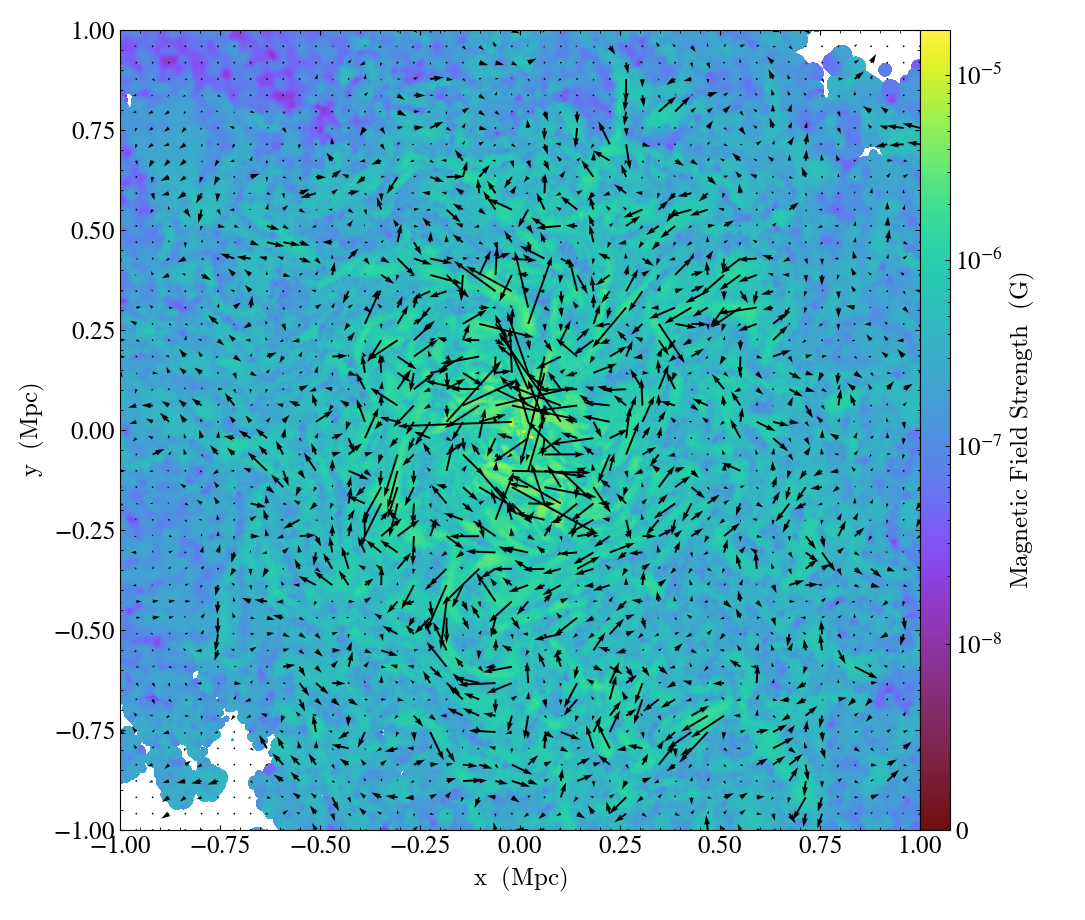
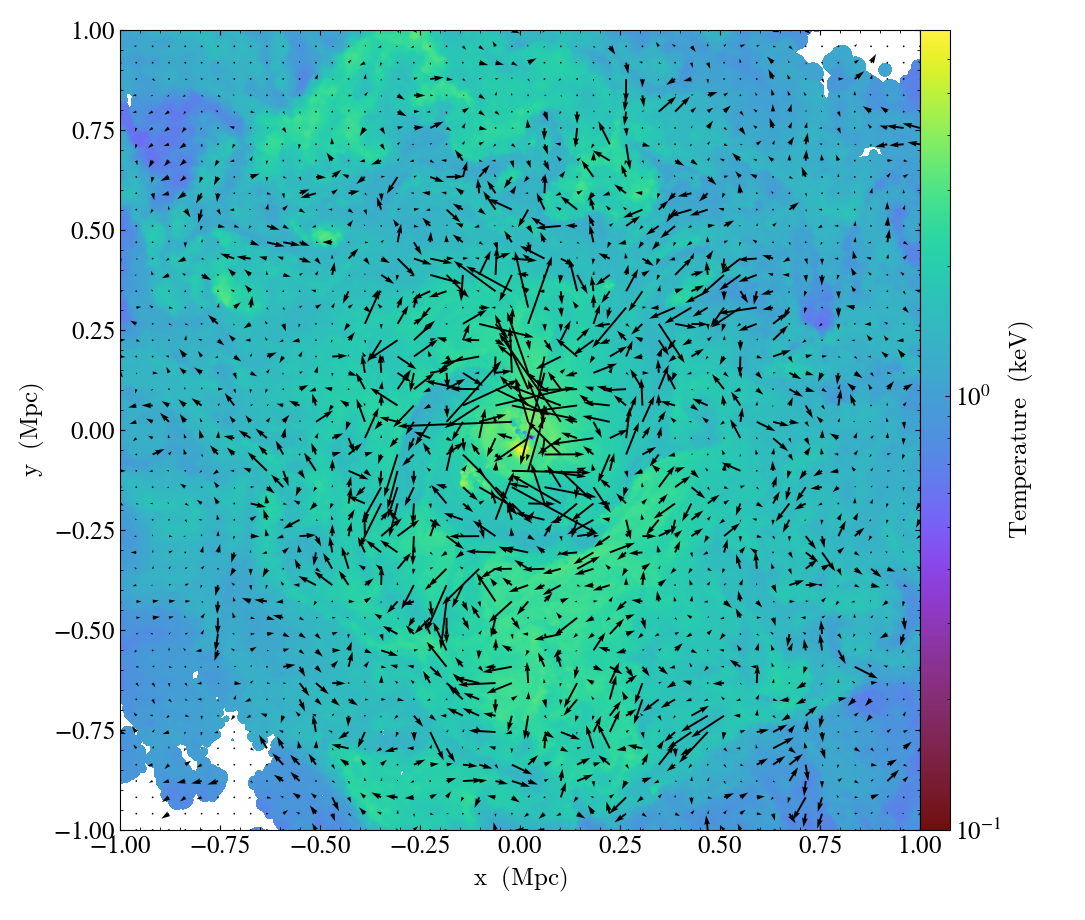
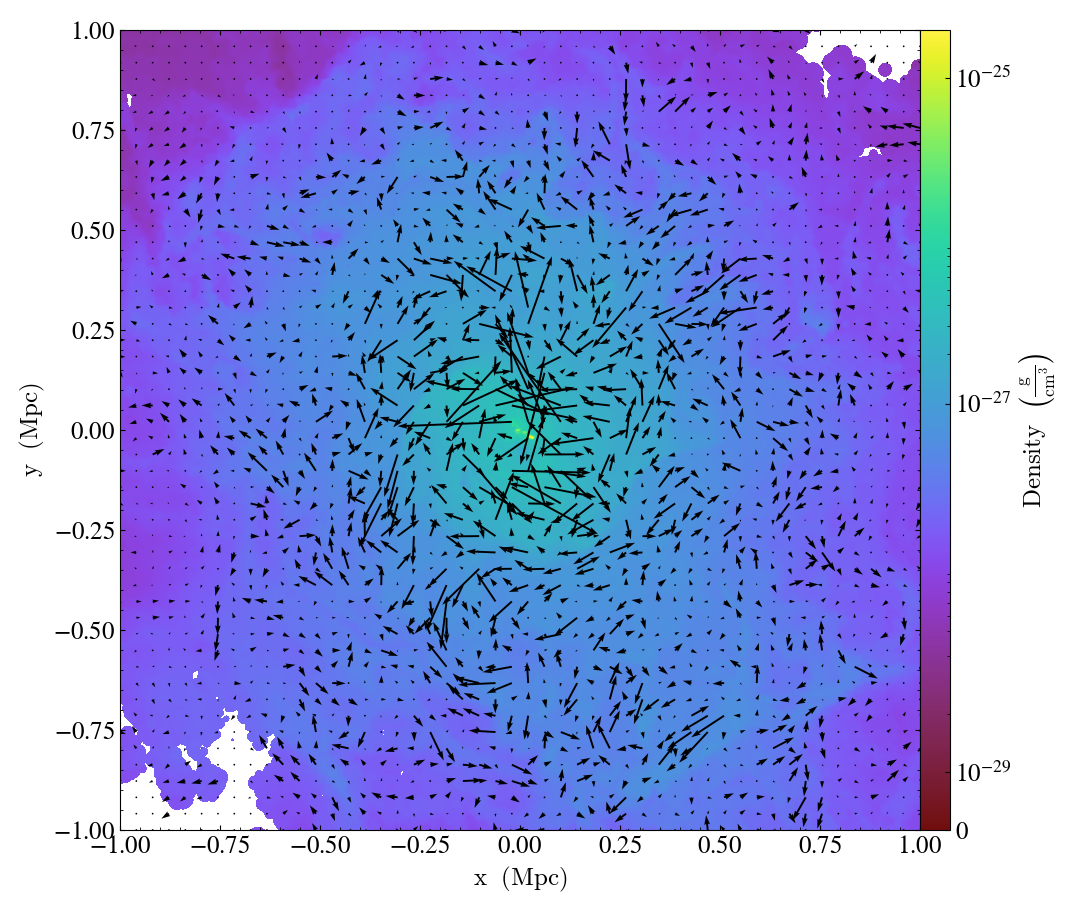

In [4]:
slc = yt.SlicePlot(
    ds,
    "z",
    [("gas", "density"), ("gas", "kT"), ("gas", "magnetic_field_strength")],
    center=c,
    width=(2.0, "Mpc"),
)
slc.annotate_magnetic_field()
slc.set_zlim(("gas", "kT"), 0.1, 7.0)
slc.show()

In [5]:
# This is the width of the grid on a side (here in kpc, but could be anything)
W = ds.arr([1000.0] * 3, "kpc")
ddims = [256] * 3

In [6]:
grid = ds.r[
    c[0] - W[0] / 2 : c[0] + W[0] / 2 : ddims[0] * 1j,
    c[1] - W[1] / 2 : c[1] + W[1] / 2 : ddims[1] * 1j,
    c[2] - W[2] / 2 : c[2] + W[2] / 2 : ddims[2] * 1j,
]

In [7]:
# This is a class I wrote to simplify stuff
fa = FourierAnalysis(W, ddims)

In [8]:
B = np.array([
    grid[("gas", "magnetic_field_x")].to_value("uG"),
    grid[("gas", "magnetic_field_y")].to_value("uG"),
    grid[("gas", "magnetic_field_z")].to_value("uG")
])

In [9]:
# here I am applying a hanning window to the data to
# fix the fact that this is a non-periodic box and avoid aliasing
fa.window_data(B, filter_function="tukey")

In [15]:
# Get the power spectrum of each spatial component
nbins = 60  # Number of bins for the power spectrum, it will
# use the min-max wavenumbers as boundaries
kbins, Pk = fa.make_powerspec(B, nbins)

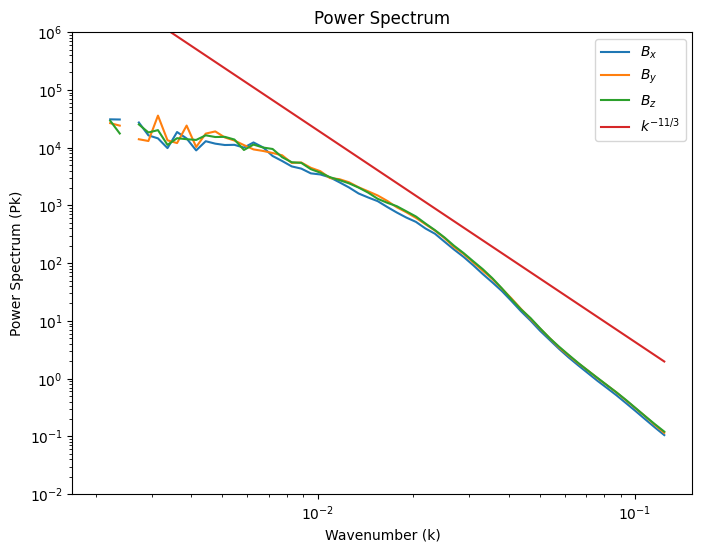

In [ ]:
# Take the geometric mean of the bins since they are logspaced
k = np.sqrt(kbins[1:]*kbins[:-1])

# Now let's plot both the magnetic field power spectra in all three components and  
# a reference Kolmogorov slope
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.loglog(k, Pk[0], label="$B_x$")
ax.loglog(k, Pk[1], label="$B_y$")
ax.loglog(k, Pk[2], label="$B_z$")
ax.loglog(k, 2e4*(k/1.0e-2)**(-11./3.), label="$k^{-11/3}$")
ax.set_xlabel("Wavenumber (k)")
ax.set_ylabel("Power Spectrum (Pk)")
ax.set_title("Power Spectrum")
ax.set_ylim(1.0e-2, 1.0e6)
ax.legend()